# Clustering với k-Means

**Sinh viên:** Phan Lê Huy Hoàng — **MSSV:** 24738541

In [1]:
import numpy as np
import matplotlib
from matplotlib import pyplot as plt

np.set_printoptions(precision=3, suppress=True)

## 1. Dữ liệu giả định

**Giả sử có 3 tập**
1. Set 1: 50 điểm
1. Set 2: 75 điểm
1. Set 3: 100 điểm

In [2]:
np.random.seed(1)
x1,y1 = np.random.normal(loc=2,scale=1,size=50), np.random.normal(loc=5,scale=1,size=50)
x2,y2 = np.random.normal(loc=5,scale=1,size=75), np.random.normal(loc=1,scale=1,size=75)
x3,y3 = np.random.normal(loc=8,scale=1,size=100), np.random.normal(loc=7,scale=1,size=100)

**=== Hiển thị 3 tập để kiểm tra ===**

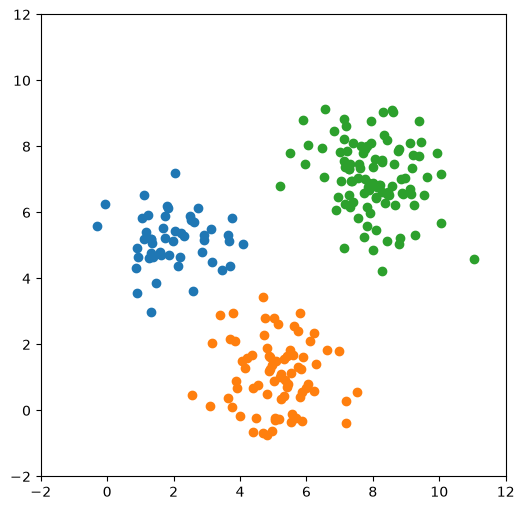

In [3]:
fig = plt.figure(figsize=(6,6))
plt.xlim([-2,12])
plt.ylim([-2,12])

plt.scatter(x1, y1)
plt.scatter(x2, y2)
plt.scatter(x3, y3)
plt.show()

### Ghép nối dữ liệu lại thành 1 tập chưa được clustered

In [4]:
dat1 = np.stack([x1, y1]).T
dat1.shape

(50, 2)

In [5]:
dat2 = np.stack([x2,y2]).T
dat3 = np.stack([x3,y3]).T

**=== Tập dữ liệu giả định có 225 dòng, 2 cột (x,y) ===**

In [6]:
dat = np.vstack([dat1, dat2, dat3])
dat.shape

(225, 2)

### Sắp ngẫu nhiên các dòng

In [7]:
np.random.seed(2)
np.random.shuffle(dat)

### Kiểm tra lại với biểu đồ scatter

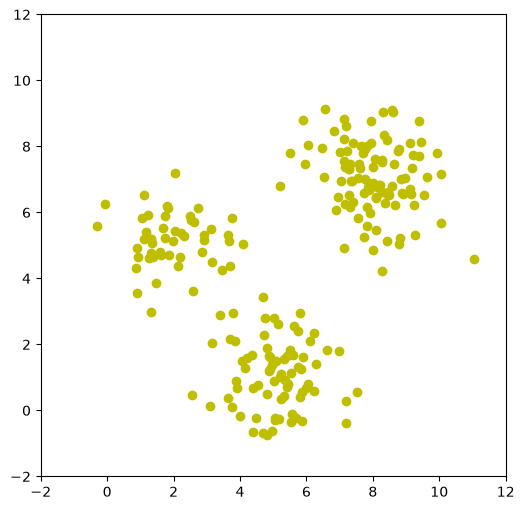

In [8]:
fig = plt.figure(figsize=(6,6))
plt.xlim([-2,12])
plt.ylim([-2,12])

plt.scatter(dat[:,0], dat[:,1], color='y')
plt.show()

## 2. Thực hiện phân cụm

### 2.1. Giả sử K=3 và tìm 3 điểm ban đầu ngẫu nhiên

In [9]:
K = 3

In [10]:
np.random.seed(30)
idx = np.random.choice(len(dat), size=K, replace=False)
print(idx)

[  8 180 170]


**Gán các trung tâm cho 3 điểm này**

In [11]:
centroids = dat[idx].copy()
print(centroids)

[[5.338 0.438]
 [2.617 5.698]
 [4.9   1.243]]


**=== Vẽ K điểm centroids ban đầu lên biểu đồ ===**

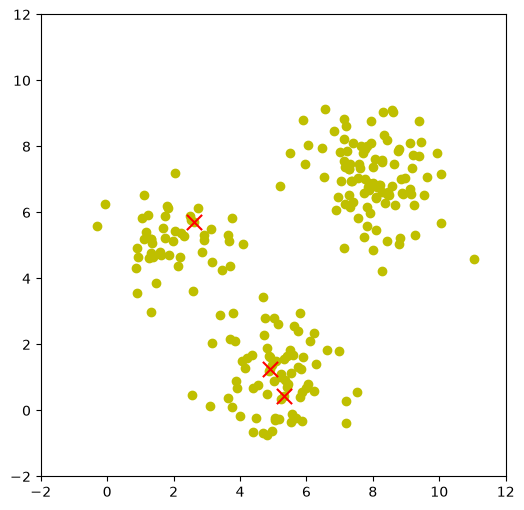

In [12]:
fig = plt.figure(figsize=(6,6))
plt.xlim([-2,12])
plt.ylim([-2,12])

plt.scatter(dat[:,0], dat[:,1], color='y')
plt.scatter(centroids[:,0], centroids[:,1], color='r', marker='x', s=120)

plt.show()

### 2.2. Tiến hành gom cụm lần 1

**=== Khởi tạo K danh sách rỗng (để chứa các điểm của mỗi cluster) ===**

In [13]:
cList = [[] for _ in range(K)]
print(cList)

[[], [], []]


**=== Với mỗi sample, tìm xem nó gần điểm centroid nào nhất ===**

In [14]:
for sample in dat:
    kc = np.sum((sample - centroids) ** 2, axis=1)
    cList[np.argmin(kc)].append(sample)

In [15]:
# Thử kiểm tra lại mỗi list
for i in range(K): print(len(cList[i]))

29
138
58


**=== Thử lấy cluster đầu tiên ra và đánh giá ===**

In [16]:
np.stack(cList[0]).shape

(29, 2)

In [17]:
np.stack(cList[0]).mean(axis=0)

array([5.584, 0.19 ])

**=== Tính lại các điểm centroids ===**

In [18]:
centroids = np.array([np.mean(cList[i], axis=0) if len(cList[i]) > 0 else centroids[i] for i in range(K)])
print(centroids)

[[5.584 0.19 ]
 [5.764 6.535]
 [5.594 2.377]]


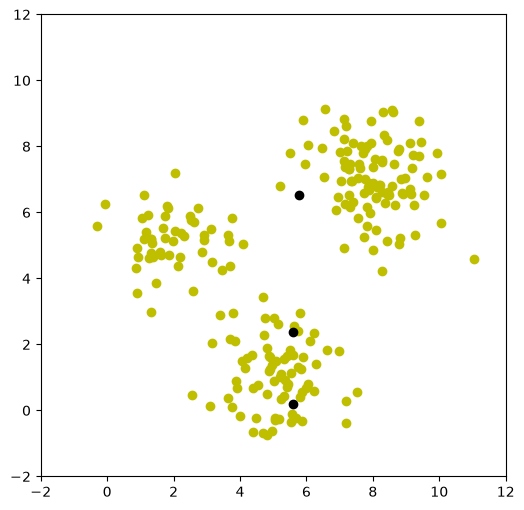

In [19]:
fig = plt.figure(figsize=(6,6))
plt.xlim([-2,12])
plt.ylim([-2,12])

plt.scatter(dat[:,0], dat[:,1], color='y')
plt.scatter(centroids[:,0], centroids[:,1], color='k')

plt.show()

### 2.3. Tiến hành gom cụm lần 2

**=== Tiếp tục khởi tạo K list rỗng để chứa các cluster mới ===**

In [20]:
cList = [[] for _ in range(K)]
for sample in dat:
    kq = np.sum((sample - centroids)**2, axis=1)
    min_d_idx = np.argmin(kq)
    cList[min_d_idx].append(sample)

# Tính giá trị của các centroids mới
centroids = [np.stack(cList[i]).mean(axis=0) for i in range(K)]
centroids = np.stack(centroids)
print(centroids)

[[5.099 0.36 ]
 [6.268 6.612]
 [4.451 2.574]]


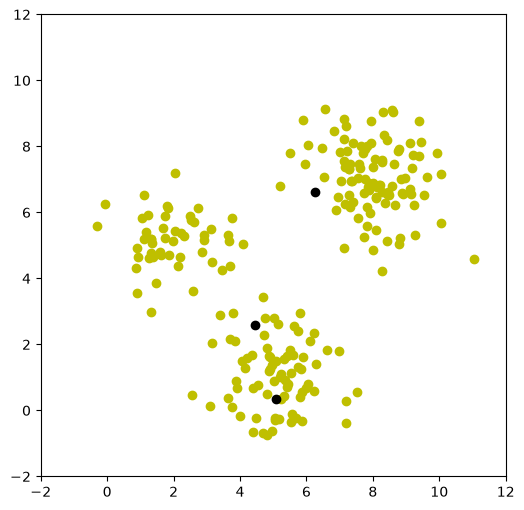

In [21]:
fig = plt.figure(figsize=(6,6))
plt.xlim([-2,12])
plt.ylim([-2,12])

plt.scatter(dat[:,0], dat[:,1], color='y')
plt.scatter(centroids[:,0], centroids[:,1], color='k')

plt.show()

### 2.4. Tiến hành gom cụm lần 3

**=== Tiếp tục khởi tạo K list rỗng để chứa các cluster mới ===**

In [22]:
cList = [[] for _ in range(K)]
for sample in dat:
    kq = np.sum((sample - centroids)**2, axis=1)
    min_d_idx = np.argmin(kq)
    cList[min_d_idx].append(sample)

centroids = [np.stack(cList[i]).mean(axis=0) for i in range(K)]
centroids = np.stack(centroids)
print(centroids)

[[5.225 0.569]
 [7.744 7.031]
 [2.898 4.079]]


**==> Nhận xét: các giá trị trung tâm gần như ít thay đổi**

In [23]:
# Lặp tiếp đến khi tâm ổn định, tối đa 100 vòng
for vong in range(100):
    cList = [[] for _ in range(K)]
    for sample in dat:
        kc = np.sum((sample - centroids) ** 2, axis=1)
        cList[np.argmin(kc)].append(sample)
    new_centroids = np.array([np.mean(cList[i], axis=0) if len(cList[i]) > 0 else centroids[i] for i in range(K)])
    da_dung = np.allclose(centroids, new_centroids)
    centroids = new_centroids
    if da_dung:
        break
clusters = [np.array(c) for c in cList]
print('Số vòng lặp thêm:', vong + 1)
print('Số điểm mỗi cụm:', [len(c) for c in clusters])
print('Tâm cuối:', centroids)

Số vòng lặp thêm: 4
Số điểm mỗi cụm: [75, 100, 50]
Tâm cuối: [[5.087 1.087]
 [8.016 7.064]
 [1.974 5.147]]


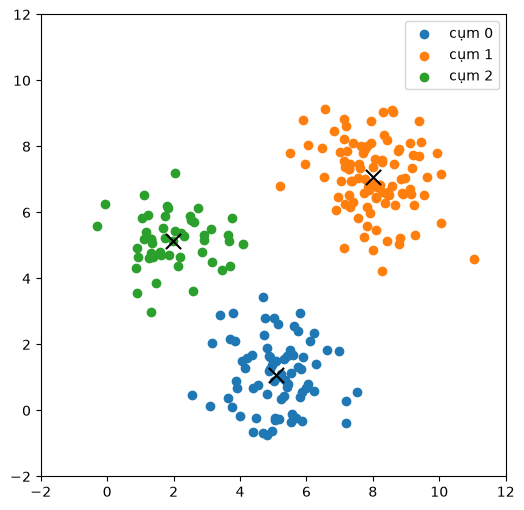

In [24]:
# Hiển thị 3 cluster lên biểu đồ
fig = plt.figure(figsize=(6,6))
plt.xlim([-2,12])
plt.ylim([-2,12])

for i, pts in enumerate(clusters):
    plt.scatter(pts[:, 0], pts[:, 1], label=f'cụm {i}')
plt.scatter(centroids[:, 0], centroids[:, 1], color='black', marker='x', s=120)
plt.legend()

plt.show()

**Nhận xét:** Các tâm dần ổn định gần ba vùng sinh dữ liệu. Mỗi vòng gán điểm vào tâm gần nhất rồi lấy trung bình các điểm trong cụm để cập nhật tâm. Tâm ban đầu có thể ảnh hưởng kết quả.